In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)


# Exploratory Data Analysis
This notebook explores NS railway disruption data (2011–2025).


In [3]:
import glob

files = glob.glob("../data/raw/*.csv")

df_list = [pd.read_csv(f) for f in files]
df = pd.concat(df_list, ignore_index=True)

df.head()


,rdt_id,ns_lines,rdt_lines,rdt_lines_id,rdt_station_names,rdt_station_codes,cause_nl,cause_en,statistical_cause_nl,statistical_cause_en,cause_group,start_time,end_time,duration_minutes
0,5171,Vlissingen-Roosendaal,Roosendaal - Vlissingen,21,NaN,NaN,aanrijding met een persoon,person hit by a train,aanrijding met een persoon,person hit by a train,accidents,2013-01-01 07:39:01,2013-01-01 11:19:01,202.0
1,5172,Alkmaar-Haarlem/Zaandam,"Alkmaar - Amsterdam Centraal, Haarlem - Uitgeest","111,161",NaN,NaN,aanrijding met een persoon,person hit by a train,aanrijding met een persoon,person hit by a train,accidents,2013-01-02 09:52:01,2013-01-02 09:54:02,2.0
2,5173,Alkmaar-Haarlem/Zaandam,"Alkmaar - Amsterdam Centraal, Haarlem - Uitgeest","111,161",NaN,NaN,inzet van de politie,police action,inzet van de politie,police action,external,2013-01-02 10:06:01,2013-01-02 11:09:01,10.0
3,5174,Utrecht Centraal-Schiphol,"Amsterdam Centraal - Utrecht Centraal, Amsterd...","136,137,141",NaN,NaN,defecte trein,broken down train,defecte trein,broken down train,rolling stock,2013-01-02 14:01:00,2013-01-02 21:21:01,422.0
4,5175,Eindhoven-Venlo,Eindhoven - Venlo,65,NaN,NaN,aanrijding met een persoon,person hit by a train,aanrijding met een persoon,person hit by a train,accidents,2013-01-02 17:17:01,2013-01-02 20:27:01,163.0


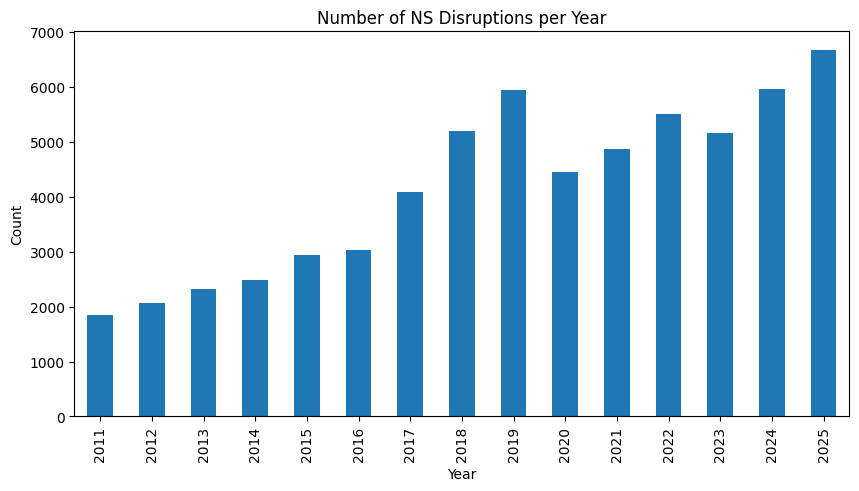

In [4]:
df["start_time"] = pd.to_datetime(df["start_time"])
df["year"] = df["start_time"].dt.year

yearly = df.groupby("year").size()

yearly.plot(kind="bar")
plt.title("Number of NS Disruptions per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


### Observation
There is a noticeable increase in reported disruptions after 2017, likely due to changes in NS reporting systems.


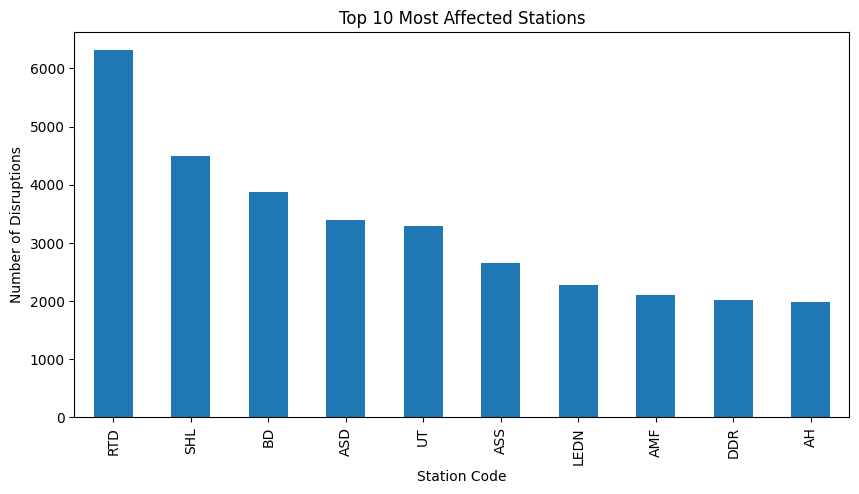

In [5]:
# Split stations and explode
stations = (
    df["rdt_station_codes"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_stations = stations.value_counts().head(10)

top_stations.plot(kind="bar")
plt.title("Top 10 Most Affected Stations")
plt.xlabel("Station Code")
plt.ylabel("Number of Disruptions")
plt.show()


### Observation
Major hub stations such as RTD and SHL appear most frequently in disruption records, likely due to high traffic volume.


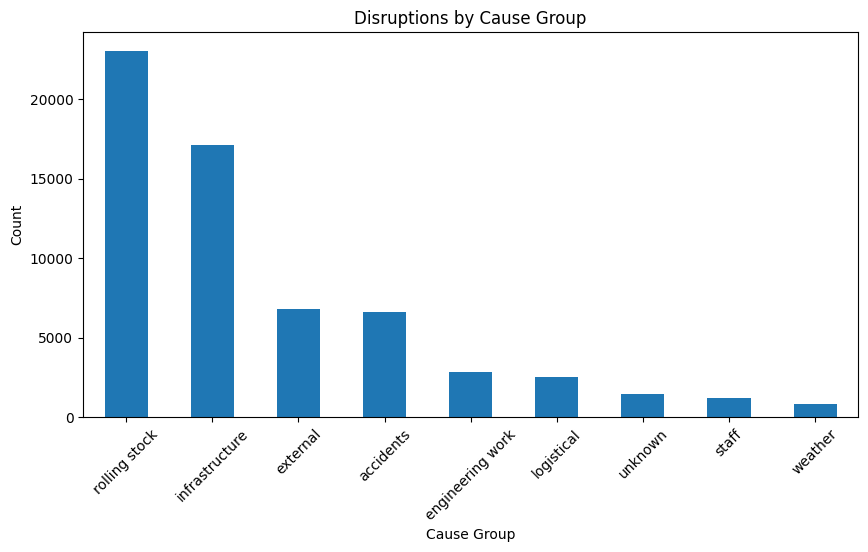

In [6]:
cause_counts = df["cause_group"].value_counts()

cause_counts.plot(kind="bar")
plt.title("Disruptions by Cause Group")
plt.xlabel("Cause Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Observation
Infrastructure and rolling stock account for the majority of major disruptions.


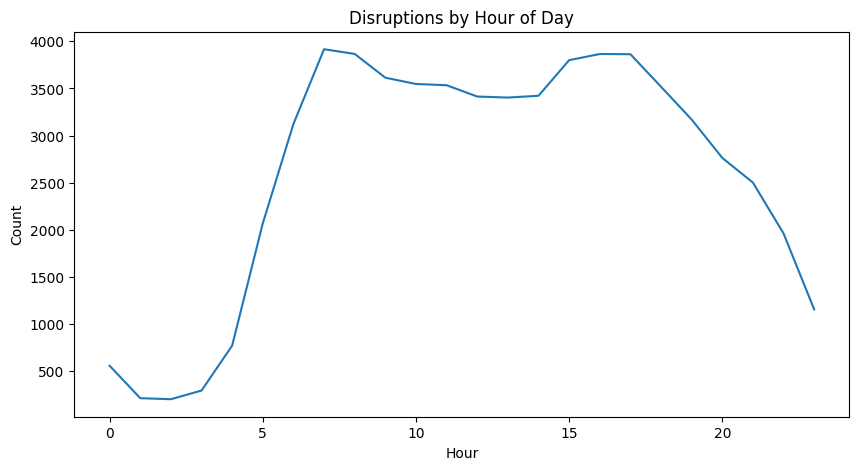

In [7]:
df["hour"] = df["start_time"].dt.hour
hourly = df.groupby("hour").size()

hourly.plot()
plt.title("Disruptions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


### Observation
Disruptions peak during morning and evening rush hours.


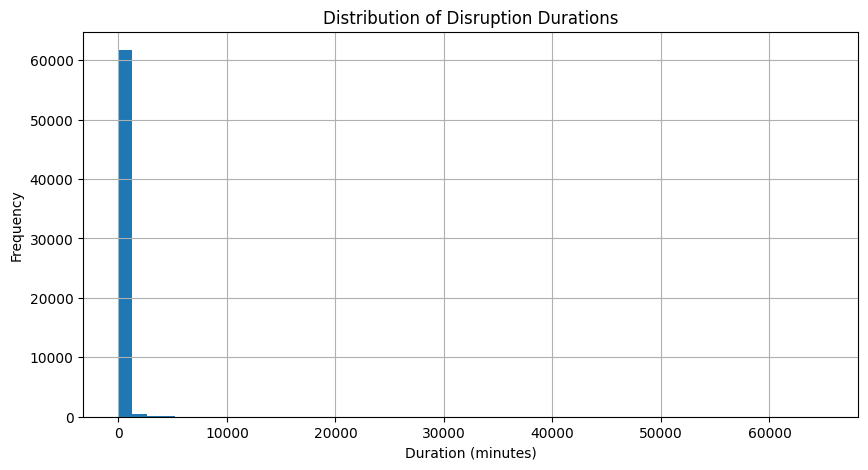

In [8]:
df["duration_minutes"].hist(bins=50)
plt.title("Distribution of Disruption Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()


### Observation
Most disruptions are short, but a long tail of severe disruptions exists.
